In [1]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import torch
import torch.nn as nn
import numpy as np
import os
from PIL import Image, ImageDraw
import zarr
from tqdm.notebook import tqdm
import json
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.filters import frangi , hessian , meijering
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2
import segmentation_models_pytorch as smp
from torchview import draw_graph
import albumentations as A

In [2]:
import numpy as np
from joblib import Parallel, delayed
from skimage.filters import frangi , sato,threshold_otsu
from skimage import img_as_float32
import SimpleITK as sitk
from concurrent.futures import ThreadPoolExecutor, as_completed

In [3]:
def vesselness_filter(input_dir,output_dir,sigmas = [1,2,3,4,5,6]):
    img_names = os.listdir(input_dir)
    windows = {}
    diams = {}

    def _process_one(name):
        img_path = os.path.join(input_dir,name)
        out_path = os.path.join(output_dir,name)

        img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None  # unreadable file, skip

        v = sato(img, black_ridges=True, sigmas=sigmas)
        th = threshold_otsu(v)
        d = (v>th).astype(np.uint8)*255

        cv2.imwrite(out_path,d)

        # return (h*w, (h, w, name),[int(x0),int(x1),int(y0),int(y1)])

    # tweak max_workers as you like; this is a reasonable default
    max_workers = 8

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_process_one, name) for name in img_names]
        for f in tqdm(as_completed(futures), total=len(futures)):
            res = f.result()
            if res is None:
                continue
            k, v, crop_dims = res
            diams[k] = v
            windows[v[-1]]=crop_dims


In [4]:
vesselness_filter(input_dir="../syntax/train/images/",output_dir="../dataset/syntax/sato/train/")
vesselness_filter(input_dir="../syntax/val/images/",output_dir="../dataset/syntax/sato/val/")
vesselness_filter(input_dir="../syntax/test/images/",output_dir="../dataset/syntax/sato/test/")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

In [6]:
with open("./crop_train.json","w") as f:
    json.dump(windows,f)

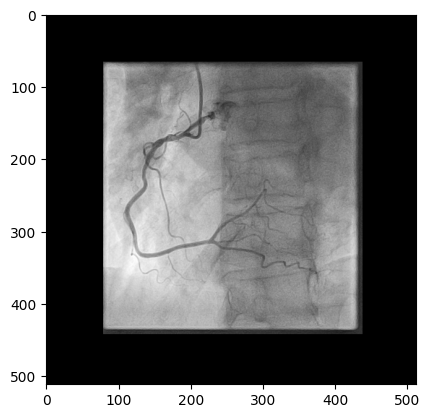

In [6]:
img = cv2.imread("../syntax/train/images/207.png",cv2.IMREAD_GRAYSCALE)
plt.imshow(img,cmap="gray")

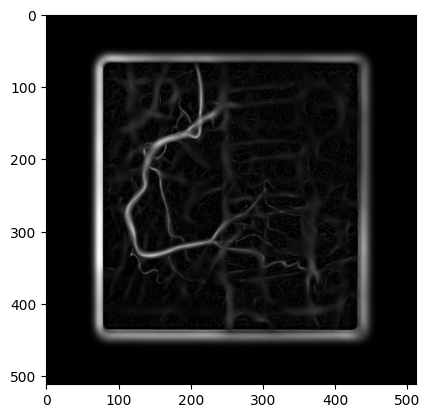

In [9]:
sigmas = [1,2,3,4,5,6]
v = sato(img, black_ridges=True,sigmas = sigmas)
plt.imshow(v,cmap="gray")

(511, 511)


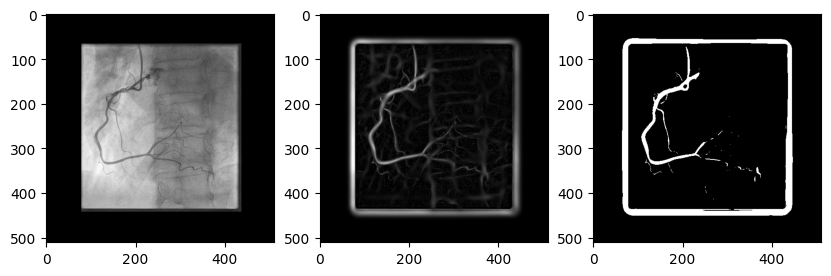

In [13]:
mask = v==0
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() 
x0, x1 = xs.min(), xs.max()


th = threshold_otsu(v)
d = v
d = (d>th).astype(np.uint8)

new_img = img[y0:y1,x0:x1]
new_mask = v[y0:y1,x0:x1]
d = d[y0:y1,x0:x1]
print(new_img.shape)
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(new_img,cmap="gray")
plt.subplot(1,3,2)
plt.imshow(new_mask,cmap="gray")
plt.subplot(1,3,3)
plt.imshow(d,cmap="gray")

In [66]:
ys

array([  6,   6,   6, ..., 494, 494, 494], shape=(8880,))

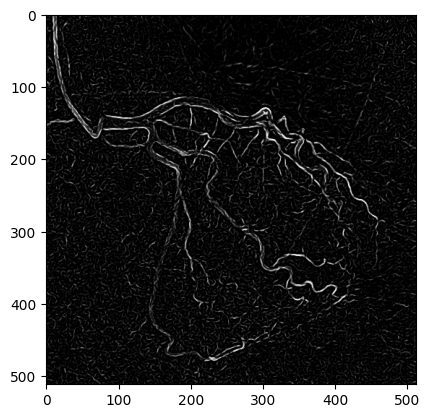

In [10]:
# usage
sigmas = [1,2,3,4,6,8,10,12,15,18]  # add bigger scales
v = frangi(img, sigmas=sigmas,
           black_ridges=True,
           alpha=0.5, beta=0.5, gamma=5)
plt.imshow(v,cmap="gray")

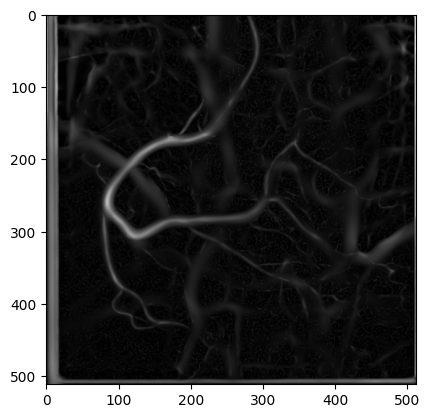

In [39]:
def read_images(base_path, part,preprocessor,max_workers=None,chosen_labels = None):
    base_path = Path(base_path)
    images_base = base_path / "images" / part
    labels_base = base_path / "labels" / part
    skels_base = base_path / "skels" / part

    image_names = sorted([p.name for p in os.scandir(images_base) if p.is_file()])
    if(not preprocessor):
        print("NOTE : preprocessor is not defined . no preprocessing will be used !")
    def _read_one(fname):
        name_stem = Path(fname).stem
        img_path = images_base / fname
        label_path = labels_base / f"{name_stem}.zarr"
        # skel_path = skels_base / fname

        # skel_img = cv2.imread(str(skel_path), cv2.IMREAD_GRAYSCALE)/255.0
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if(preprocessor):
            img = preprocessor(img)
        label = zarr.load(str(label_path))
        if(chosen_labels is not None):
            temp = np.zeros_like(label)
            for i,l in enumerate(chosen_labels):
                temp[label==l]=i+1
            label = temp
        return img, label , name_stem

    if max_workers is None:
        cpu = os.cpu_count() or 4
        max_workers = min(32, cpu * 4)

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for img, label , name_stem in tqdm(ex.map(_read_one, image_names), total=len(image_names)):
            results.append([img,label,name_stem])

    return results
    

In [40]:
args = {
    "base_path" : "../../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 3 ,
    "attention" : False,
    "k":40,
    "batch_size" : 20,
    "num_workers" : 5,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":30,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "15-14b-4layer",
    "deep_super_vision" : True,
    "f_alpha":None,
    "layer_count":4
}
# class_map = {
#     1: '1',2: '2', 3: '3',4: '4',
#     5: '5',6: '6',7: '7',8: '8',
#     9: '9',10: '9a',11: '10',12: '10a',
#     13: '11',14: '12',15: '12a',16: '13',
#     17: '14',18: '14a',19: '15',20: '16',
#     21: '16a',22: '16b',23: '16c',
#     24: '12b',25: '14b'
# }
class_map = {
    1:'15',
    2:'14b'
}
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = 7 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights



[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]

In [41]:
train_images = read_images(
    base_path = args["base_path"],
    preprocessor = None,
    part = "train",
    chosen_labels=[19,25]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = None,
    part = "val",
    chosen_labels=[19,25]
)


NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]